In [6]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Conv2D,AveragePooling2D,Flatten
from keras import Sequential
from keras.datasets import mnist

In [25]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

## LeNet Architecture

In [26]:
model = Sequential()

model.add(Conv2D(6,kernel_size = (5,5),padding='valid',activation = 'tanh',input_shape = (28,28,1)))
model.add(AveragePooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Conv2D(16,kernel_size = (5,5),padding = 'valid',activation = 'tanh'))
model.add(AveragePooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Flatten())
model.add(Dense(120,activation = 'tanh'))
model.add(Dense(84,activation = 'tanh'))
model.add(Dense(10,activation = 'softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

In [30]:
model.fit(X_train, Y_train, epochs=8, validation_data=(X_test, Y_test), verbose=1)

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9717 - loss: 0.0929 - val_accuracy: 0.9786 - val_loss: 0.0672
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9812 - loss: 0.0620 - val_accuracy: 0.9836 - val_loss: 0.0533
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.9849 - loss: 0.0475 - val_accuracy: 0.9844 - val_loss: 0.0471
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9871 - loss: 0.0400 - val_accuracy: 0.9857 - val_loss: 0.0420
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9898 - loss: 0.0329 - val_accuracy: 0.9843 - val_loss: 0.0467
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.9893 - val_loss: 0.0313
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9922 - loss: 0.0248 - val_accuracy: 0.9883 - val_loss: 0.0371
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9928 - loss: 0

In [31]:
model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9871 - loss: 0.0441


[0.044111549854278564, 0.9871000051498413]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


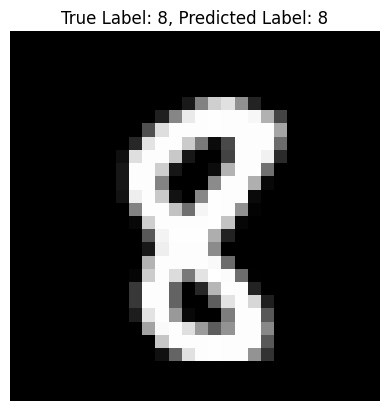

Model Prediction Probabilities: [[2.87201397e-06 3.07839154e-03 3.72875576e-07 2.32129278e-05
  1.16385809e-05 1.15240087e-04 1.11750505e-05 1.32308451e-05
  9.96742785e-01 1.01718024e-06]]
Predicted Digit: 8
True Digit: 8


In [37]:
import random
import numpy as np
import matplotlib.pyplot as plt
index = random.randint(0, len(X_test) - 1)
random_digit = X_test[index]
true_label = Y_test[index]

processed_digit = random_digit.reshape(1, 28, 28, 1).astype('float32') / 255.0

prediction = model.predict(processed_digit)
predicted_label = np.argmax(prediction)

plt.imshow(random_digit, cmap='gray')
plt.title(f"True Label: {true_label}, Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()

print(f"Model Prediction Probabilities: {prediction}")
print(f"Predicted Digit: {predicted_label}")
print(f"True Digit: {true_label}")